In [2]:
import rasterio
import rasterio.mask
import r5py as r5
import h3
import geopandas as gpd
from shapely.geometry import Polygon, box
from scipy.spatial.distance import jensenshannon
from scipy.stats import entropy
from pyrosm import OSM
import numpy as np
from pyrosm.data import sources
from pyrosm import get_data
import matplotlib.pyplot as plt
import pandas as pd
from datetime import timedelta
import wkls
from reusable import *

d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\sedonadb\context.py:520: UserWarning: Failed to configure PROJ. Is pyproj or a system install of PROJ available?
Details: tried ['pyproj', 'conda', 'homebrew', 'system']
pyproj: Expected PROJ dll/so directory 'd:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\pyproj.libs' does not exist
conda: Can't load PROJ shared library 'D:\hp\Documents\Scripts\r5py\.conda\lib\libproj.dylib': Could not find module 'D:\hp\Documents\Scripts\r5py\.conda\lib\libproj.dylib' (or one of its dependencies). Try using the full path with constructor syntax.
homebrew: Can't configure PROJ from prefix '\opt\homebrew': does not exist
system: Can't load PROJ shared library 'proj.dll': Could not find module 'proj.dll' (or one of its dependencies). Try using the full path with constructor syntax.
  warnings.warn(


### **Boundaries and setup**

In [7]:
osm_path = "cities\paris\Paris.osm.pbf"
gtfs_path = "cities\paris\80921.20260312.121737.836569.zip"
pop_path = r"cities\\paris\\fra_pd_2020_1km.tif"
bound_path = "cities\paris\\arrondissements-75-paris.geojson"

In [8]:
osm = OSM(osm_path)
boundaries = osm.get_boundaries()

In [12]:
wanted = [
    "Paris",
    "Hauts-de-Seine",
    "Seine-Saint-Denis",
    "Val-de-Marne",
]

selected = boundaries[boundaries["name"].isin(wanted)]

In [4]:
tn = r5.TransportNetwork(osm_path, gtfs=gtfs_path)

In [13]:
local_crs = selected.estimate_utm_crs()
city_proj = selected.to_crs(local_crs)

<Axes: >

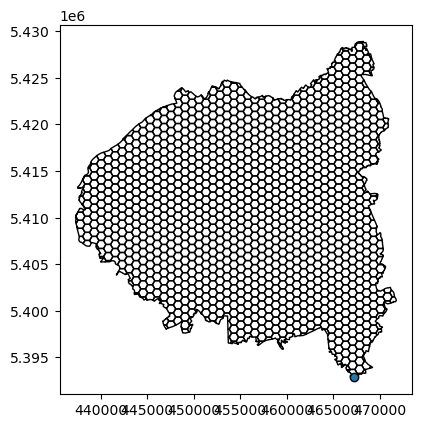

In [14]:
grid = create_hex_grid(city_proj, 500)
grid.plot(edgecolor='black', facecolor='none')

#### **Populating the grid**

Raster total population:  4,129,968
Hex grid total population: 4,006,129
Coverage: 97.0%


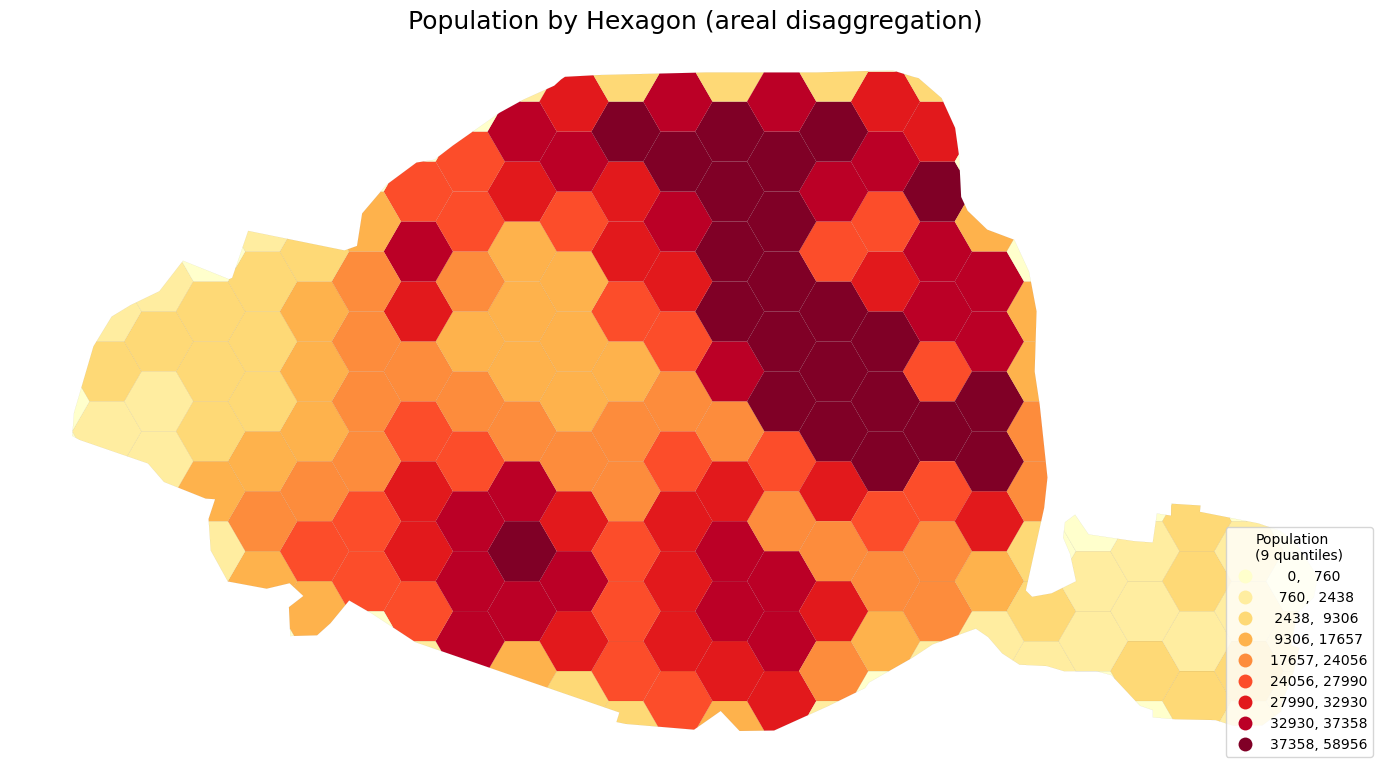

In [8]:
grid_pop = assign_population_to_grid(pop_path, grid, plot=True)

In [9]:
result_geo = build_city_geojson(
    grid=grid,
    grid_pop=grid_pop,
    osm=osm,
    tn=tn,
    output_path="data/paris_scores.geojson",
    transport_modes=[r5.TransportMode.TRANSIT, r5.TransportMode.WALK],
    max_time=25,
    beta=0.0277,
    gravity_normalisation=100,
)

d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\r5py\r5\regional_task.py:205: RuntimeWarning: The currently loaded GTFS data sets do not define any services on 2026-05-05.
  warnings.warn(


City-wide baseline distribution:
  count_community: 0.027
  count_education: 0.100
  count_essential_services: 0.078
  count_food_and_drink: 0.685
  count_healthcare: 0.099
  count_shelter: 0.011


In [6]:
suggested_beta(60,0.2)

0.026823965207235005

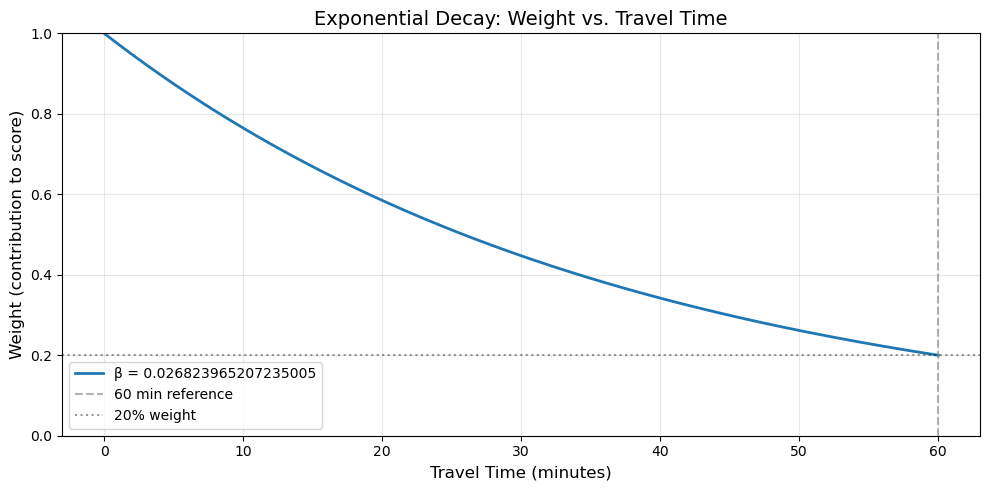

In [7]:
def plot_decay_curves(betas, max_time=60, cutoff_line=30, target_weight=0.1):
    t = np.linspace(0, max_time, 300)

    fig, ax = plt.subplots(figsize=(10, 5))
    for beta in betas:
        ax.plot(t, np.exp(-beta * t), label=f"β = {beta}", linewidth=2)

    ax.axvline(cutoff_line, color="grey", linestyle="--", alpha=0.6,
               label=f"{cutoff_line} min reference")
    ax.axhline(target_weight, color="black", linestyle=":", alpha=0.4,
               label=f"{int(target_weight * 100)}% weight")

    ax.set_xlabel("Travel Time (minutes)", fontsize=12)
    ax.set_ylabel("Weight (contribution to score)", fontsize=12)
    ax.set_title("Exponential Decay: Weight vs. Travel Time", fontsize=14)
    ax.legend()
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_decay_curves(betas=[0.026823965207235005], cutoff_line=60, target_weight=0.2)


#### **Origins**

In [22]:
origins = create_origins(grid, grid_pop)
origins.head(5)

,geometry,id,population
0,POINT (2.32454 48.82159),0,7904.347682
1,POINT (2.29504 48.82687),1,1386.568600
2,POINT (2.31385 48.82469),2,10868.960602
3,POINT (2.335 48.81821),3,5448.822324
4,POINT (2.35519 48.81808),4,9305.753689


#### **Destinations (POIs)**

In [23]:
destinations = create_POIs(osm, summary=True)

Total amenities: 83872

By type:
amenity class
food_and_drink        28378
education              9748
healthcare             7091
essential_services     5546
motorcycle_parking     3526
ticket_validator       2877
community              2793
drinking_water         2254
toilets                2079
shelter                1963


#### **Results and Visualisation**

Define categories of interest among the amenity classes to measure

In [24]:
categories = ['food_and_drink','shelter','essential_services','education','healthcare','community']
essentials = destinations[destinations['amenity class'].isin(categories)]

Compute travel time matrix between all origins and points of interest, deifining threshold for max. travel time and modes of transport

In [25]:
travel_time_matrix = r5.TravelTimeMatrix(
    tn,
    origins=origins,
    destinations=essentials,
    transport_modes=[r5.TransportMode.TRANSIT, r5.TransportMode.WALK],
    max_time=timedelta(minutes=20) #CUTOFF
)

d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\r5py\r5\regional_task.py:205: RuntimeWarning: The currently loaded GTFS data sets do not define any services on 2026-04-30.
  warnings.warn(


Calculate score for basic metrics (minimum travel time, basic counts (no gravity), weighted counts (gravity))

In [26]:
min_tt_wide = min_travel_time(travel_time_matrix, essentials)

In [27]:
no_gravity = compute_gravity_scores(travel_time_matrix, destinations=essentials, beta=0)

In [28]:
gravity = compute_gravity_scores(travel_time_matrix, destinations=essentials, beta=0.0644)

Adjusting for population & diversity metric

In [29]:
pop_weighed = weight_pop(gravity, origins, score_cols=["gravity_food_and_drink"], normalisation=1000)

In [30]:
cols = [x for x in no_gravity.columns if x not in ['from_id','avg_gravity']]
diversity = compute_diversity_scores(no_gravity, count_cols=cols)

City-wide baseline distribution:
  gravity_community: 0.027
  gravity_education: 0.099
  gravity_essential_services: 0.077
  gravity_food_and_drink: 0.687
  gravity_healthcare: 0.099
  gravity_shelter: 0.011


### **Result Plotting**

In [31]:
gravity = merge_geometry(gravity, grid=grid)
res = merge_geometry(min_tt_wide, grid)
pop_weighed = merge_geometry(pop_weighed, grid)
no_gravity = merge_geometry(no_gravity, grid=grid)
diversity = merge_geometry(diversity, grid=grid)

In [32]:
def plot_hex_score(results_geo, score_col, from_id_col="from_id", scheme="Quantiles",
                   k=9, cmap="viridis", title=None, figsize=(14, 12),
                   legend_fmt="{:.1f}", ax=None, show=True):

    n_missing = results_geo[score_col].isna().sum()
    if n_missing > 0:
        print(f"Note: {n_missing} hexes have NaN for '{score_col}' and will appear grey.")

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=figsize)

    results_geo.plot(
        column=score_col,
        cmap=cmap,
        scheme=scheme,
        k=k,
        legend=True,
        linewidth=0.02,
        edgecolor="none",
        missing_kwds={"color": "lightgrey", "label": "No data"},
        legend_kwds={
            "loc": "upper left",
            "bbox_to_anchor": (1.02, 1),
            "fmt": legend_fmt
        },
        ax=ax
    )

    ax.set_title(title if title else score_col.replace("_", " ").title(), fontsize=18)
    ax.set_axis_off()

    if show:
        plt.tight_layout()
        plt.show()

In [36]:
import os, json
import geopandas as gpd

def to_df(gdf):
    if "geometry" in gdf.columns:
        return gdf.drop(columns="geometry")
    return gdf

# ── Rename no_gravity columns: gravity_X → count_X ───────────────────────────

counts = to_df(no_gravity).copy()
counts = counts.rename(columns={
    c: c.replace("gravity_", "count_")
    for c in counts.columns if c.startswith("gravity_")
})
# also rename avg_gravity → avg_count if present
if "avg_gravity" in counts.columns:
    counts = counts.rename(columns={"avg_gravity": "avg_count"})

# ── Merge everything on from_id ───────────────────────────────────────────────

master = (
    to_df(gravity)
    .merge(to_df(min_tt_wide), on="from_id", how="left")
    .merge(to_df(pop_weighed), on="from_id", how="left")
    .merge(to_df(diversity),   on="from_id", how="left")
    .merge(counts,             on="from_id", how="left")   # ← counts added
)

# ── Attach geometry & export ──────────────────────────────────────────────────

master_geo = merge_geometry(master, grid)
master_geo["city"] = "paris"

os.makedirs("data", exist_ok=True)
out = master_geo.to_crs("EPSG:4326").copy()
out["from_id"] = out["from_id"].astype(str)
out.to_file("data/paris_scores.geojson", driver="GeoJSON")

print(f"Features : {len(out)}")
print(f"Count cols: {[c for c in out.columns if c.startswith('count_')]}")
print(f"All cols  : {[c for c in out.columns if c != 'geometry']}")

Features : 202
Count cols: ['count_community', 'count_education', 'count_essential_services', 'count_food_and_drink', 'count_healthcare', 'count_shelter']
All cols  : ['from_id', 'gravity_community', 'gravity_education', 'gravity_essential_services', 'gravity_food_and_drink', 'gravity_healthcare', 'gravity_shelter', 'avg_gravity', 'min_tt_community', 'min_tt_education', 'min_tt_essential_services', 'min_tt_food_and_drink', 'min_tt_healthcare', 'min_tt_shelter', 'avg_tt', 'n_unreachable_categories', 'gravity_food_and_drink_per_1000', 'shannon', 'kl_divergence', 'jsd', 'city_similarity', 'count_community', 'count_education', 'count_essential_services', 'count_food_and_drink', 'count_healthcare', 'count_shelter', 'avg_count', 'city']


In [ ]:
def build_city_geojson(
    grid,
    grid_pop,
    osm,
    tn,
    output_path=None,
    transport_modes=None,
    max_time=60,
    beta=0.08,
    gravity_normalisation=100,
):
    """
    Builds a fully-scored GeoJSON for a city by running the complete
    accessibility pipeline on a hex grid.

    Parameters
    ----------
    grid : GeoDataFrame
        Hex grid polygon GeoDataFrame (any CRS).
    grid_pop : GeoDataFrame
        Population-annotated hex grid (output of assign_population_to_grid).
    osm : pyrosm.OSM
        OSM object for the city.
    tn : r5py.TransportNetwork
        Pre-built R5 transport network.
    output_path : str, optional
        If provided, saves the output as a GeoJSON at this path.
    transport_modes : list, optional
        r5py transport modes. Defaults to [TransportMode.TRANSIT, TransportMode.WALK].
    max_time : int
        Maximum travel time in minutes (default 60).
    beta : float
        Decay parameter for gravity scores (default 0.08).
    gravity_normalisation : int
        Population normalisation factor for weighted scores (default 100).

    Returns: GeoDataFrame: Fully scored hex grid with all accessibility metrics attached.
    """

    if transport_modes is None:
        transport_modes = [r5.TransportMode.TRANSIT, r5.TransportMode.WALK]

    # --- Origins and destinations from grid and OSM ---
    origins      = create_origins(grid, grid_pop=grid_pop)
    destinations = create_POIs(osm)

    # --- Travel time matrix via r5py ---
    ttm = r5.TravelTimeMatrixComputer(
        tn,
        origins=origins,
        destinations=destinations,
        transport_modes=transport_modes,
        max_time=timedelta(minutes=max_time),
    )

    # --- Gravity scores (exponential decay per amenity category) ---
    gravity = compute_gravity_scores(ttm.copy(), destinations, beta=beta)

    # --- Min + average travel time per amenity category ---
    tt_stats = min_travel_time(ttm.copy(), destinations)

    # --- Basic counts: gravity with beta=0 equals a simple reachable amenity count ---
    counts_raw = compute_gravity_scores(ttm.copy(), destinations, beta=0)
    counts_wide = counts_raw.rename(columns={
        c: c.replace("gravity_", "count_") for c in counts_raw.columns if c.startswith("gravity_")
    })
    counts_wide = counts_wide.drop(columns=["avg_gravity"], errors="ignore")

    # --- Population-weighted gravity (score per N inhabitants) ---
    gravity_cols = [c for c in gravity.columns if c.startswith("gravity_")]
    pop_weighted = weight_pop(
        gravity,
        origins,
        score_cols=gravity_cols,
        normalisation=gravity_normalisation,
        return_full=False,
    )

    # --- Diversity scores (Shannon, JSD, KL divergence, city similarity) ---
    count_cols = [c for c in counts_wide.columns if c.startswith("count_")]
    diversity = compute_diversity_scores(counts_wide, count_cols=count_cols, id_col="from_id")

    # --- Merge all score dataframes on from_id ---
    result = origins[["id"]].rename(columns={"id": "from_id"}).copy()
    for df in [gravity, tt_stats, counts_wide, pop_weighted, diversity]:
        df["from_id"] = df["from_id"].astype(str)
        result = result.merge(df, on="from_id", how="left")

    # --- Attach hex geometry back to results ---
    result_geo = merge_geometry(result, grid)

    # --- Optionally save to GeoJSON ---
    if output_path:
        result_geo.to_file(output_path, driver="GeoJSON")

    return result_geo

In [ ]:
result_geo = build_city_geojson(
    grid=grid,
    grid_pop=grid_pop,
    osm=osm,
    tn=tn,
    output_path="data/paris_scores.geojson",
    transport_modes=[r5.TransportMode.TRANSIT, r5.TransportMode.WALK],
    max_time=25,
    beta=0.08,
    gravity_normalisation=100,
)